In [10]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import matplotlib.pyplot as plt
from DataLoader.data_loader import DataLoader
from ClusteringAlgorithms.clustering_module import CLARANS, ROCK

In [5]:
n_samples = 300
loader = DataLoader(n_samples=n_samples)

### Toy Datasets from scikit-learn

In [14]:
datasets = {
    "Blobs": loader.get_blobs(),
    "Circles": loader.get_circles(factor=0.5, noise=0.05),
    "Moons": loader.get_moons(noise=0.05)
}

In [8]:
params_clarans = {'k': 2, 'numlocal': 2, 'maxneighbor': 3}
params_rock = {'k': 2, 'theta': 0.4}

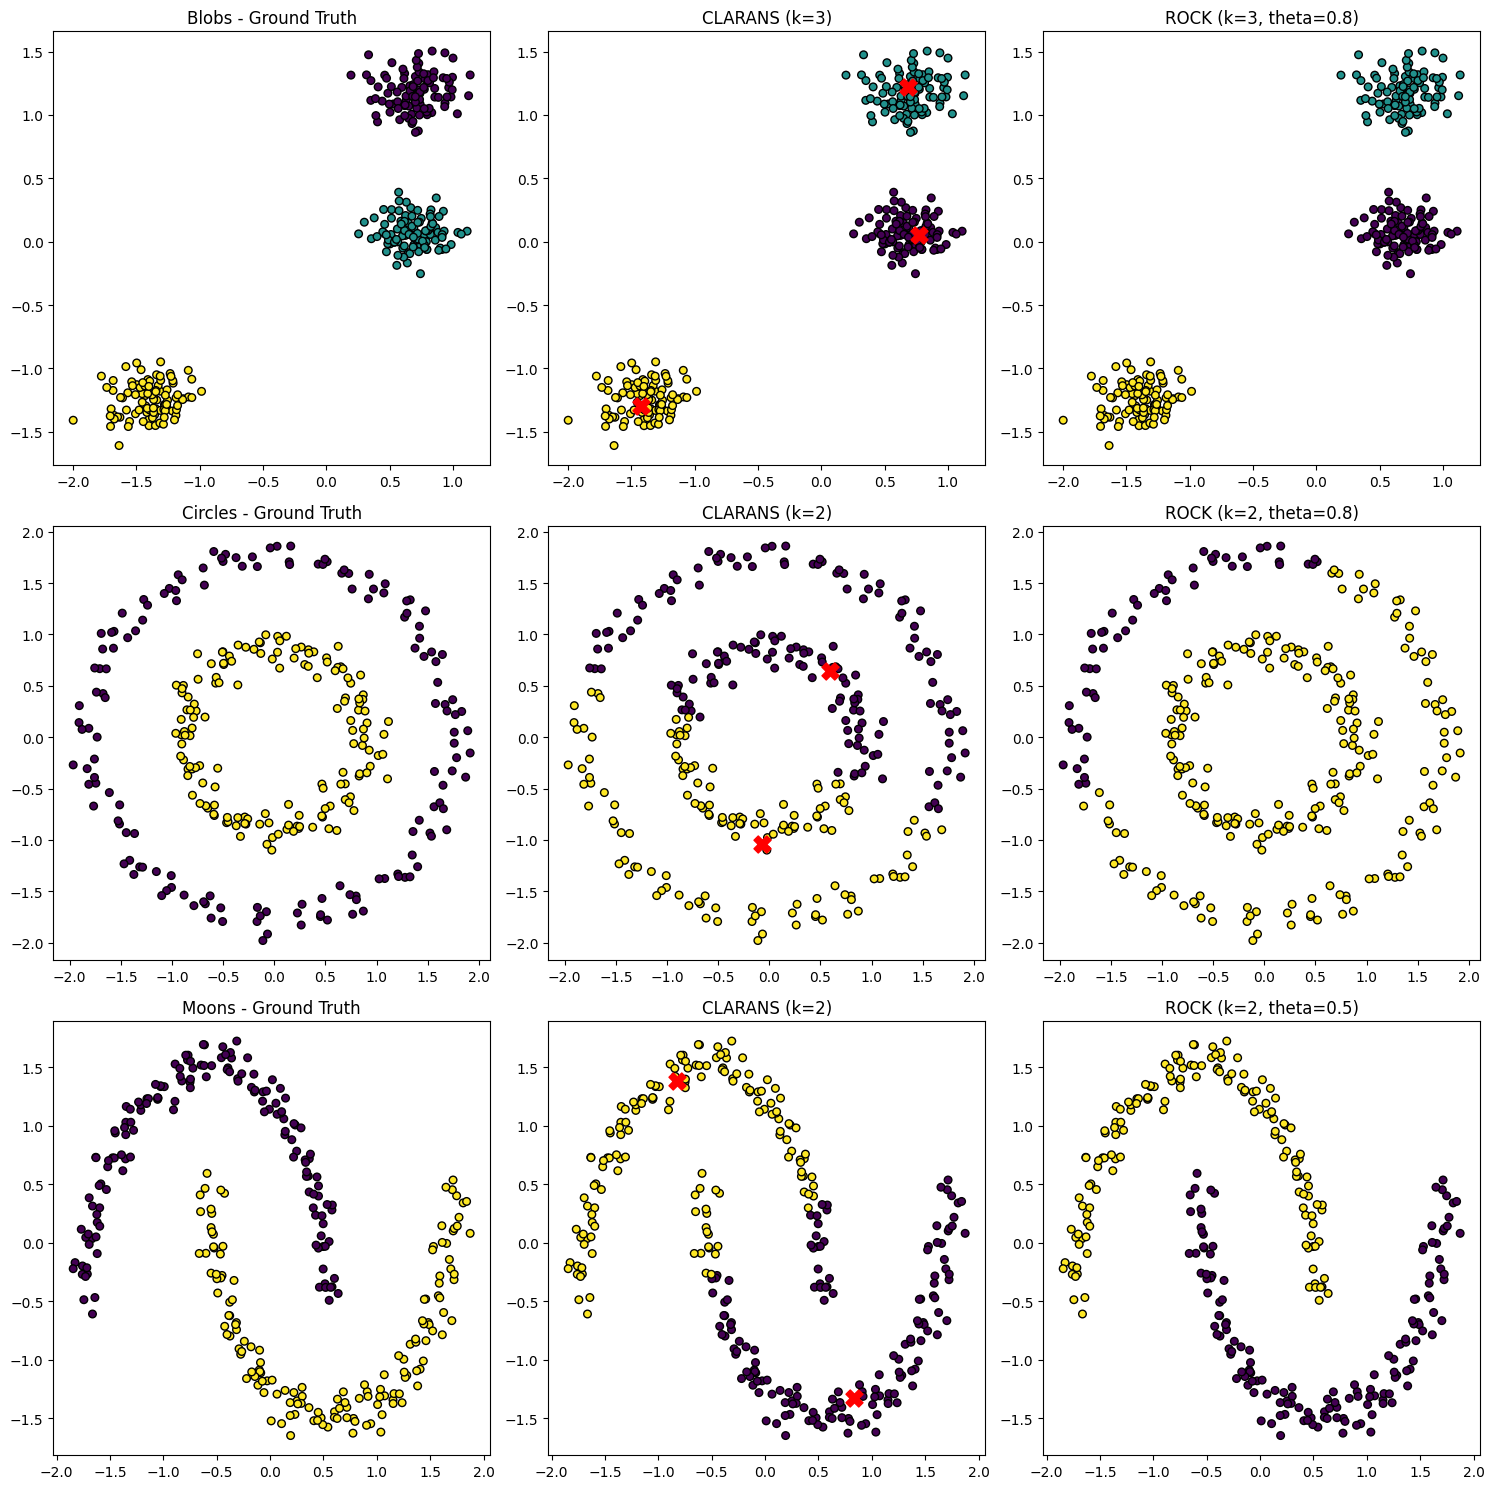

In [15]:
fig, axes = plt.subplots(len(datasets), 3, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)

for idx, (name, (X, y_true)) in enumerate(datasets.items()):
    
    # For Blobs K=3, for others K=2
    k_clusters = 3 if name == "Blobs" else 2
    
    # Original Data
    axes[idx, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 0].set_title(f"{name} - Ground Truth")
    
    # CLARANS
    clarans = CLARANS(k=k_clusters, numlocal=3, maxneighbor=5)
    clarans.fit(X)
    axes[idx, 1].scatter(X[:, 0], X[:, 1], c=clarans.labels_, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 1].scatter(clarans.medoids_vectors_[:, 0], clarans.medoids_vectors_[:, 1], 
                         c='red', marker='X', s=150, label='Medoids')
    axes[idx, 1].set_title(f"CLARANS (k={k_clusters})")
    
    # ROCK
    # We empirically choose theta for ROCK based on the dataset characteristics (normalized with a scaler)
    theta_val = 0.5 if name == "Moons" else 0.8
    rock = ROCK(k=k_clusters, theta=theta_val)
    rock.fit(X)
    axes[idx, 2].scatter(X[:, 0], X[:, 1], c=rock.labels_, cmap='viridis', s=30, edgecolor='k')
    axes[idx, 2].set_title(f"ROCK (k={k_clusters}, theta={theta_val})")

plt.tight_layout()
plt.show()